In [16]:
from ctw.models import BivariateQuantizer
import numpy as np

In [17]:
thresholds = np.array([
    [-0.1, 0.1],
    [-0.1, 0.1]
])

bq = BivariateQuantizer(thresholds=thresholds)
inputs = np.array([
    [0.05, 0.05],
    [-0.05, 0.05],
    [0.05, -0.05],
    [-0.05, -0.05],
    [0.15, 0.15],
    [-0.15, 0.15],
    [0.15, -0.15],
    [-0.15, -0.15]
])
for inp in inputs:
    print(f"Input: {inp}, Quantized: {bq.quantize(inp)}")

print(len(bq.alphabet))

# Plot 2D serie and 2D quantized serie

Input: [0.05 0.05], Quantized: 3
Input: [-0.05  0.05], Quantized: 3
Input: [ 0.05 -0.05], Quantized: 3
Input: [-0.05 -0.05], Quantized: 3
Input: [0.15 0.15], Quantized: 3
Input: [-0.15  0.15], Quantized: 2
Input: [ 0.15 -0.15], Quantized: 1
Input: [-0.15 -0.15], Quantized: 0
4


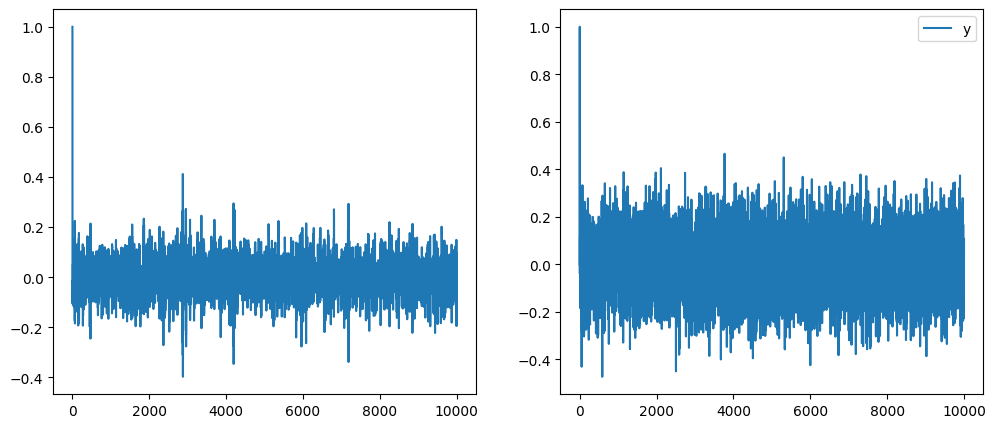

In [18]:
import numpy as np

## Parameters
n_samples = 10000
order = 2
max_depth = 3

positive_ar_coeff = [1, -0.1]
positive_var = 0.01

negative_ar_coeff = [-0.5, 0.5]
negative_var = 0.05

ar_coeff_y = [0.7, -0.3]
var_y = 0.1

def generate_dual_ar(init_seq_x, init_seq_y, n_samples) :
    x = init_seq_x[:]
    y = init_seq_y[:]
    for _ in range(n_samples) :
        if y[-1] > 0 :
            x.append(positive_ar_coeff[0]*x[-1] + positive_ar_coeff[1]*x[-2] + np.random.normal(0, positive_var))
        else :
            x.append(negative_ar_coeff[0]*x[-1] + negative_ar_coeff[1]*x[-2] + np.random.normal(0, negative_var))
        
        y.append(ar_coeff_y[0]*y[-1] + ar_coeff_y[1]*y[-2] + np.random.normal(0, var_y))

    return x, y

x, y = generate_dual_ar(init_seq_x = [1, 0], init_seq_y = [0, 1], n_samples=n_samples)
thresholds = np.concatenate([[0, 100], 
                             [0,100]], axis = 0).reshape(2, -1)

# Plot x and y
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, label='x')
plt.subplot(1, 2, 2)
plt.plot(y, label='y')
plt.legend()


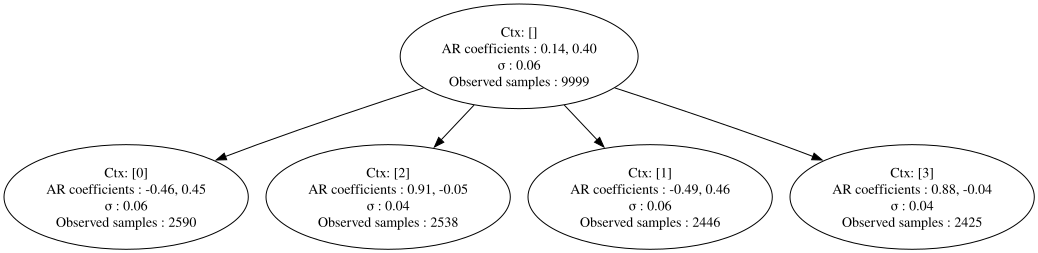

In [19]:
from ctw.models import BivariateQuantizer, BivariateARTree
from ctw.tree import view_tree
bq = BivariateQuantizer(thresholds=thresholds)
tree = BivariateARTree(order=order, max_depth=max_depth, quantizer=bq)
for x, y in zip(x, y) :
    tree.observe(x, y)

view_tree(tree.tree)
